In [ ]:
import pandas as pd
#匯入檔案
df=pd.read_excel('nba2.xlsx')

In [ ]:
df.head()

,DATASET,R/P,DATE,TEAMS,H/R,W/E,W/L,DIFF,1Q,2Q,3Q,4Q,F,MIN,FG,FGA,3P,3PA,FT,FTA,OR,ORR,DRR,FT%,TOV%,EFG%,DRB%,ORB%,DR,TOT,A,PF,ST,TO,BL,PTS,POSS,PACE,OEFF,DEFF,REST DAYS,OPENING ODDS,SPREAD
0,2016-2017 Regular Season,1,10/25/2016,New York,2,1,0,-29,18,27,19,24,88,240,32,87,9,27,15,20,13,11,40,0.172414,0.158172,0.419540,0.725000,0.245283,29,42,17,22,6,18,6,88,100.4,100.4,87.7,116.6,3,205.5,9.5
1,2016-2017 Regular Season,1,10/25/2016,Cleveland,1,1,1,29,28,20,34,35,117,240,45,94,13,35,14,19,11,13,29,0.148936,0.120316,0.547872,0.754717,0.275000,40,51,31,22,12,14,5,117,100.4,100.4,116.6,87.7,3,-9.5,-9.5
2,2016-2017 Regular Season,1,10/25/2016,Utah,2,2,0,-9,26,20,37,21,104,240,40,82,8,24,16,16,6,5,29,0.195122,0.109956,0.536585,0.833333,0.171429,25,31,19,19,9,11,5,104,92.5,92.5,112.4,122.1,3,194.0,6.0
3,2016-2017 Regular Season,1,10/25/2016,Portland,1,2,1,9,26,28,23,36,113,240,39,75,13,19,22,22,5,6,25,0.293333,0.124121,0.606667,0.828571,0.166667,29,34,22,18,5,12,3,113,92.5,92.5,122.1,112.4,3,-6.0,-6.0
4,2016-2017 Regular Season,1,10/25/2016,San Antonio,2,2,1,29,31,33,33,32,129,240,47,98,12,24,23,26,21,8,27,0.234694,0.106174,0.540816,0.809524,0.437500,34,55,25,19,13,13,3,129,98.8,98.8,130.6,101.2,3,210.5,8.0


In [ ]:
X=df[['A','DIFF']] #輸入自變數/特徵
from sklearn.model_selection import train_test_split #區分訓練集與測試集
X_train, X_test = train_test_split(X,test_size=0.25,random_state=5) 

In [ ]:
from sklearn.cluster import KMeans
KM=KMeans(n_clusters=3,init='random',random_state=5)
KM.fit(X)
KM.predict(X)

array([0, 1, 0, ..., 1, 2, 2], dtype=int32)

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
y_kmeans

array([3, 0, 1, ..., 0, 2, 1], dtype=int32)

In [ ]:
df['cluster']=y_kmeans

In [ ]:
df.head()

,DATASET,R/P,DATE,TEAMS,H/R,W/E,W/L,DIFF,1Q,2Q,3Q,4Q,F,MIN,FG,FGA,3P,3PA,FT,FTA,OR,ORR,DRR,FT%,TOV%,EFG%,DRB%,ORB%,DR,TOT,A,PF,ST,TO,BL,PTS,POSS,PACE,OEFF,DEFF,REST DAYS,OPENING ODDS,SPREAD,cluster
0,2016-2017 Regular Season,1,10/25/2016,New York,2,1,0,-29,18,27,19,24,88,240,32,87,9,27,15,20,13,11,40,0.172414,0.158172,0.419540,0.725000,0.245283,29,42,17,22,6,18,6,88,100.4,100.4,87.7,116.6,3,205.5,9.5,3
1,2016-2017 Regular Season,1,10/25/2016,Cleveland,1,1,1,29,28,20,34,35,117,240,45,94,13,35,14,19,11,13,29,0.148936,0.120316,0.547872,0.754717,0.275000,40,51,31,22,12,14,5,117,100.4,100.4,116.6,87.7,3,-9.5,-9.5,0
2,2016-2017 Regular Season,1,10/25/2016,Utah,2,2,0,-9,26,20,37,21,104,240,40,82,8,24,16,16,6,5,29,0.195122,0.109956,0.536585,0.833333,0.171429,25,31,19,19,9,11,5,104,92.5,92.5,112.4,122.1,3,194.0,6.0,1
3,2016-2017 Regular Season,1,10/25/2016,Portland,1,2,1,9,26,28,23,36,113,240,39,75,13,19,22,22,5,6,25,0.293333,0.124121,0.606667,0.828571,0.166667,29,34,22,18,5,12,3,113,92.5,92.5,122.1,112.4,3,-6.0,-6.0,2
4,2016-2017 Regular Season,1,10/25/2016,San Antonio,2,2,1,29,31,33,33,32,129,240,47,98,12,24,23,26,21,8,27,0.234694,0.106174,0.540816,0.809524,0.437500,34,55,25,19,13,13,3,129,98.8,98.8,130.6,101.2,3,210.5,8.0,0


In [ ]:
a=df.groupby('cluster').mean()
b=a[['A','DIFF']]
b

,A,DIFF
cluster,,
0,27.438547,21.812849
1,21.572917,-6.870370
2,23.033333,7.027586
3,19.453804,-21.703804


In [ ]:
c=df.groupby('cluster').count()
d=c[["A"]]
d

,A
cluster,
0,358
1,864
2,870
3,368


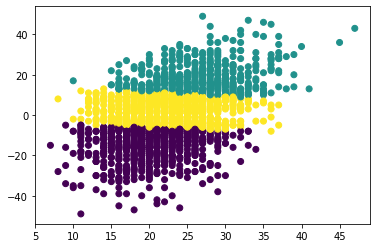

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df[['A']],df[['DIFF']],c=KM.predict(X))

In [ ]:
kmeans.predict([[-20,30]])

array([0], dtype=int32)

# **練習題**
1.請利用efa.xlsx檔案中的特徵將學生進行分群，並說明分群結果。
2.請利用efa.xlsx檔案中的特徵進行因素分析，再利用因素分析後之因素將學生進行分群，並說明分群結果。